# Partie 1

### 2.Generation of synthetic data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

Q1 & Q2

In [4]:
x_true = pd.read_table('x.txt',header=None,names=['x'])
N = 200
T_min, T_max = 1,1000
T = np.array([T_min * np.exp(np.log(T_max/T_min)*i/(N-1)) for i in range(N)])

Q3

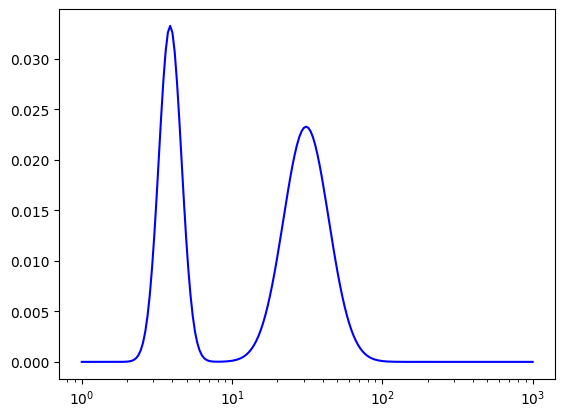

In [5]:
plt.plot(T,x_true.x, label='True', color='blue')
plt.xscale('log')

Q4 & Q5

In [6]:
M = 50
tmin, tmax = 0,1.5
t = np.array([tmin + (tmax - tmin)*i/(M-1) for i in range(M)])
K = np.exp(-np.outer(t,T))

Q6

In [7]:
z = K@x_true.x
sigma = 0.01 * z[0]
w = np.random.normal(loc=np.zeros(M), scale=sigma,size=(M,))
y = z + w

Q7

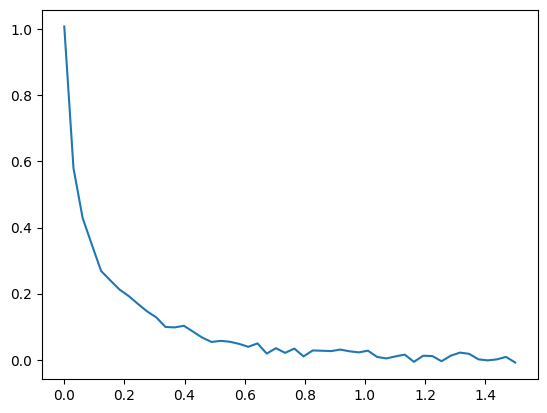

In [8]:
plt.plot(t, y)

### 3.Comparison of regularization strategies


#### Smoothness prior

$$g(x)=\frac{1}{2}||Dx||^2$$

On est dans le cas où f et g sont toutes les deux convexes et différentiables. On voit que les gradients s'expriment aisément en fonction des matrices D, K et du paramètre $\beta$, on peut simplement inverser le système matriciel. On pourrait également faire une descente de gradient ou utiliser les algorithmes forward-backward et Douglas-Racheford car les fonctions sont proximables.
$$\nabla f(\mathbf{x}) = \mathbf{K}^\top \mathbf{K} \mathbf{x} - \mathbf{K}^\top \mathbf{y}$$
$$\nabla g(\mathbf{x}) =  \mathbf{D}^\top \mathbf{D} \mathbf{x} $$
On cherche donc x vérifiant : 
$$\mathbf{x} = (\mathbf{K}^\top \mathbf{K} + \beta \mathbf{D}^\top \mathbf{D})^{-1} \mathbf{K}^\top \mathbf{y}$$
A condition que $\mathbf{K}^\top \mathbf{K} + \beta \mathbf{D}^\top \mathbf{D}$ soit inversible. Comme $\mathbf{K}^\top \mathbf{K}$ et $\beta \mathbf{D}^\top \mathbf{D}$ sont semi-définies positives et que le noyau de D ne contient que les vecteurs constants et que K n'annule pas les constantes, la matrice est bien inversible.

Best beta: 1.0
Minimum NQE: 0.2751057971383435


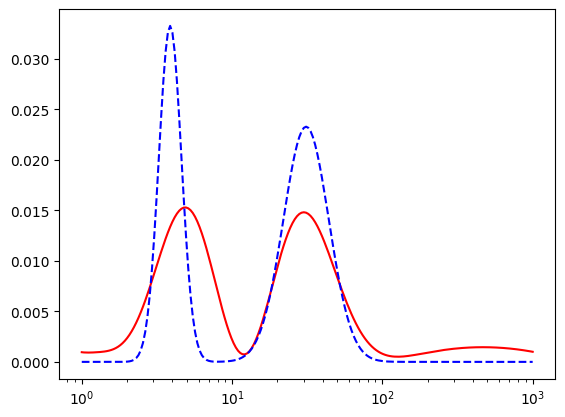

In [10]:
D = np.identity(N,dtype=float)
for i in range(1,N):
    D[i,i-1] = -1.0
D[0,N-1] = -1.0

def solve_min(K, D, y, beta):
    A = K.T @ K + beta * (D.T @ D)
    b = K.T @ y
    return np.linalg.solve(A, b)

grid_beta = np.linspace(-2,2,9)
NQE_list = [] 
for beta in grid_beta:
    res = solve_min(K, D, y, beta)
    NQE = np.sum(((res - x_true.x)**2))/np.sum((x_true.x**2))
    NQE_list.append(NQE)

best_beta = grid_beta[np.argmin(NQE_list)]
res = solve_min(K, D, y, 1)
print("Best beta:", best_beta)
print("Minimum NQE:", np.min(NQE_list))
plt.plot(T, res, label='Reconstructed', color='red')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

Cette inférence semble moche mais lorseque l'on compare les signaux (y), on voit que c'est cohérent:

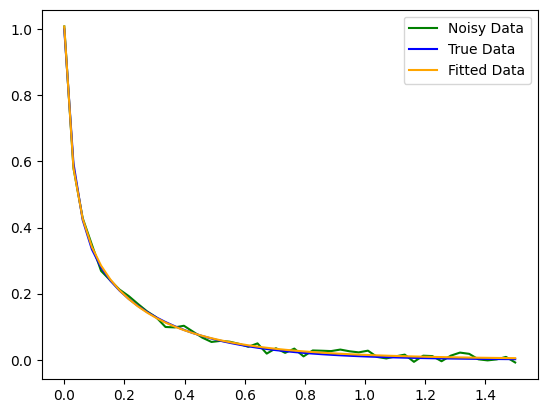

In [12]:
plt.plot(t,y, label='Noisy Data', color='green')
plt.plot(t,z, label='True Data', color='blue')
z_reconstructed = K @ res
plt.plot(t, z_reconstructed, label='Fitted Data', color='orange')
plt.legend()

Comme $f+g$ est convexe, propre, semi-continue inférieure, et qu'on peut estimer sa constante de lipschitz (plus grande valeur propre de $(\mathbf{K}^\top \mathbf{K} + \beta \mathbf{D}^\top \mathbf{D})$), on peut faire une descente de gradient. Pour assurer l'unicité de la solution, il faut que $f+g$ soit strictement convexe ce qui est le cas puisque $(\mathbf{K}^\top \mathbf{K} + \beta \mathbf{D}^\top \mathbf{D})$ est inversible.

#### Smootheness prior + constraint :

Cette fois ci g n'est plus différentiable et on ne peut plus inverser le système simplement. Comme la fonction indicatrice est proximable on peut utiliser l'algorithme forward-backward qui nous assure la convergence vers un minimum de $f+g$. La partie convexe différentiable étant strictement convexe la solution est unique.

Ici on décompose la somme comme ceci : 
$$g = g_1 + g_2 $$
Où
$$ g_1(x) = \frac{1}{2}||Dx||^2 $$
$$ g_2(x) = \iota_{[x_{min},x_{max}]^N}(x)$$

Donc on a $f+\beta*g_1$ qui est dérivable et $\beta*g_2$ proximable.

In [ ]:
def g1(x):
    return np.sum((D @ x)**2)/2

x_min, x_max = min(x_true.x), max(x_true.x)
x_init = np.mean(x_true.x)*np.ones(N)
def g2(x):
    for i in range(len(x)):
        if x[i] < x_min or x[i] > x_max:
            return np.inf
    return g1(x)

def f(x):
    Kx = K @ x
    return 0.5*np.sum((Kx - y)**2)


NQE Forward-Backward: 0.26170371162254047


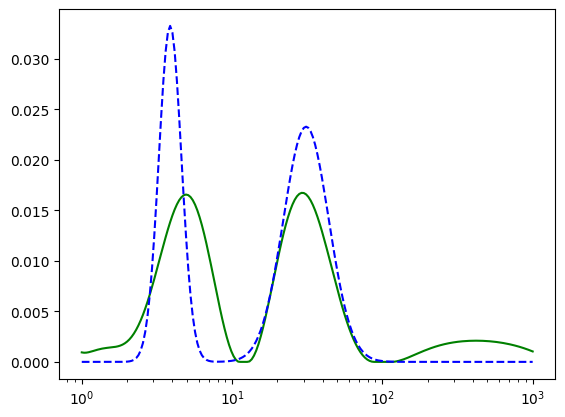

In [ ]:
## Forward - Backward optimization
import numpy as np
def proximal_indicator(v): #projection sur l'ensemble [x_min, x_max]^N
    x = np.minimum(np.maximum(v, x_min), x_max)
    return x

def forward_backward_optimization(beta, K, y, max_iter=1000,x_init=x_init):
    x_curr = x_init.copy()
    lipschitz_const = np.linalg.eigvalsh(K.T @ K + beta * D.T @ D).max()
    gamma = 1 / lipschitz_const
    delta = 2 - 2 * gamma * lipschitz_const/2
    lambda_curr = delta 

    for _ in range(max_iter):
        # Forward
        y_curr = x_curr - gamma * (K.T @ (K @ x_curr - y) + beta * (D.T @ D) @ x_curr)
        # Backward
        x_next = x_curr + lambda_curr * (proximal_indicator(y_curr) - x_curr)

        x_curr = x_next

    return x_curr

res_fb = forward_backward_optimization(0.6, K, y, max_iter=200000)
NQE_fb = np.sum(((res_fb - x_true.x)**2)/np.sum((x_true.x**2)))
print("NQE Forward-Backward:", NQE_fb) 
plt.plot(T, res_fb, label='Reconstructed FB', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

### Sparsity

$$g = ||.||_1$$

On verifie bien que $g \in \Gamma^0$ et f est strictement convexe (voir partie 2 pour la justification) donc le problème à une unique solution.
Comme g n'est pas différentiable mais proximable, on utilise Douglas Racheford. (On pourrais faire F-B mais ça permet de tester des choses)

fin
NQE D-R: 0.2505555926958943


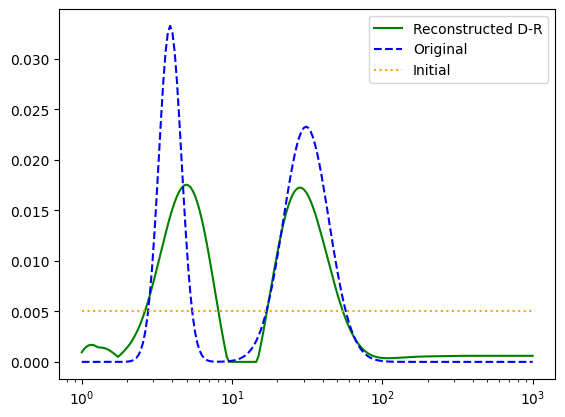

In [20]:
def prox_f(v, gamma, K, y):
    A = gamma * K.T @ K + np.eye(K.shape[1])
    rhs = gamma *K.T @ y +  v
    x = np.linalg.solve(A, rhs)
    return x

def prox_l1_vec(v, gamma):
    return np.sign(v) * np.maximum(np.abs(v) - gamma, 0.0)


def douglas_rachford(K, y, beta, gamma,x0=x_init, n_iter=200, lamb=1, tol=1e-6):
    xn = x0.copy()
    yn_list = []
    zn_list = []
    xn_list = []
    for n in range(n_iter):      
        tau = gamma * beta
        yn = prox_l1_vec(xn, tau)
        yn_list.append(yn)

        arg = 2.0 * yn - xn
        zn = prox_f(arg, gamma, K, y)
        zn_list.append(zn)

        xn1 = xn + lamb * (zn - yn)
        xn_list.append(xn1)

        resid = np.linalg.norm(xn1 - xn)
        if resid < tol:
            xn = xn1
            print(f'Converged in {n} iterations.')
            break

        xn = xn1

    x_est = prox_l1_vec(xn, tau) 
    return x_est, yn_list, zn_list, xn_list

x_sol, yn_list, zn_list, xn_list = douglas_rachford(K, y, beta = 0.05, gamma = 0.06, n_iter=1500, lamb = 1, tol=1e-6) 
print("fin")

NQE_fb = np.sum(((x_sol - x_true.x)**2)/np.sum((x_true.x**2)))
print("NQE D-R:", NQE_fb)
plt.plot(T, x_sol, label='Reconstructed D-R', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.plot(T, x_init, label='Initial', color='orange', linestyle='dotted')
plt.legend()
plt.xscale('log')
plt.show()
#avec x_true beta = 0.05, gamma = 0.001

# Partie 2

### 1)
$\varphi$ est propre ($dom(\varphi) = [0,+\inf[$ ), semi-continue inférieure car continue sur $[0,+\inf[$ (prolongement par continué $\lim_{0^+}\limits{u \log{u}}{\rightarrow 0} $), continue sur $[-\inf,0[$ et on vérifie sans peine que la limite inférieure en 0 de $\varphi$ qui vaut $+\inf$ est bien supérieure à $\varphi(0)$.
Sur $]0,+\inf[ \varphi$ est convexe car sa dérivée seconde $u \mapsto \frac{1}{u}$ est postitive. En distinguant les cas où x et y sont positifs et négatifs, on montre ensuite aisément l'inégalité vérifié par une fonction convexe. 
$$ \forall x,y \in \mathbb{R} , \forall \alpha \in [0,1] f(\alpha x + (1-\alpha)y) \leq \alpha f(x) + (1-\alpha)f(y)$$
Donc $\varphi$ est bien convexe sur $\mathbb{R}$.
Comme $ent(x)$ est la somme séparable de fonctions propres, semi-continues inférieures et convexes elle est propre, semi-continue inférieure et convexe.

### 2)
$f(x)$ est strictement convexe sur $\mathbb{R}$ car $\mathbf{K}$ est de rang plein (on reconnaît une matrice de Vandermonde, les $T^{(m)}$ étant 2 à 2 distincts, elle est pleine.) et ent(x) est convexe donc la fonction objective est strictement convexe et propre donc le problème admet une unique solution.

### 3)

$$
\operatorname{prox}_{\gamma\varphi}(x)
= \arg\min_{y \in \mathbb{R}} \left( \gamma y\log y + \frac{1}{2}(y-x)^2 \right)
= \arg\min_{y \in \mathbb{R}} h(y)
$$

$$
h'(y) = \gamma \log(y) + \gamma + y - x
$$

En composant avec l'exponentielle, on fait apparaître la fonction de Lambert :
$$
y^{\gamma} \exp(y) = \exp(x-\gamma)
$$
Puis,
$$
\frac{y}{\gamma} \exp(\frac{y}{\gamma}) = \frac{1}{\gamma}\exp(\frac{x-\gamma}{\gamma})
$$
Donc :
$$
y = \gamma W( \frac{1}{\gamma}\exp(\frac{x-\gamma}{\gamma}))
$$

Le proximal de $\mathrm{ent}(x)$ se calcule aisément en tant que somme séparable:
$$
\operatorname{prox}_{\mathrm{ent}}(x)
= \bigl(\operatorname{prox}_{\varphi}(x^{i})\bigr)_{i=1}^{N}
$$

Et on trouve :
$$
\forall \gamma \in (0,+\infty), \qquad
\operatorname{prox}_{\gamma\,\mathrm{ent}}(x)
= \biggl(\gamma\, W\!\left(\frac{1}{\gamma}
\exp\!\left(\frac{x^{i}}{\gamma}-1\right)\right)\biggr)_{i=1}^{N}.
$$
et pour x = 0 on trouve facilement $\operatorname{prox}_{\gamma\,\mathrm{ent}}(x)
= 0$

### 4) Forward-Backward

Converged in 84 iterations.
NQE Forward-Backward: 3.4141211270988503


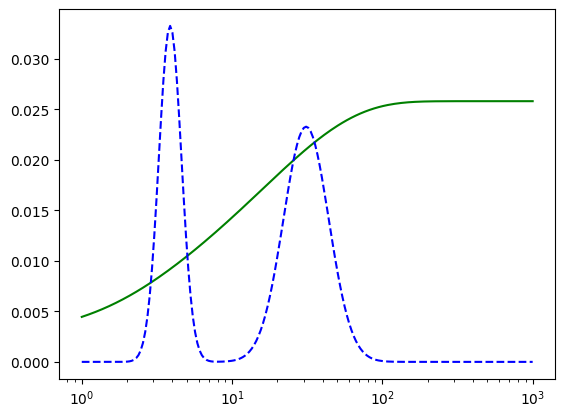

In [46]:
from scipy.special import lambertw

def prox_ent(x, gamma):
    return np.maximum(0,gamma * np.real(lambertw(np.exp((x - gamma) / gamma) / gamma)))

def forward_backward_optimization(beta, K, y, max_iter=1000,x_init=x_init, tol=1e-6):
    x_curr = x_init.copy()
    # lipschitz_const = np.linalg.norm(K, ord=2)**2 + beta * np.linalg.norm(D, ord=2)**2 #borne sup de la constante de Lipschitz du gradient de f + beta*g1
    # lipschitz_const = np.linalg.eigvalsh(K.T @ K).max() + beta * np.linalg.eigvalsh(D.T @ D).max()
    lipschitz_const = np.linalg.eigvalsh(K.T @ K).max()
    gamma = 2 / lipschitz_const
    delta = 2 -  gamma * lipschitz_const/2
    lambda_curr = delta/2 

    for _ in range(max_iter):
        # Forward
        y_curr = x_curr - gamma * (K.T @ (K @ x_curr - y))
        # Backward
        x_next = x_curr + lambda_curr * (prox_ent(y_curr, gamma) - x_curr)
        resid = np.linalg.norm(x_next - x_curr)
        if resid < tol:
            x_curr = x_next
            print(f'Converged in {_} iterations.')
            break

        x_curr = x_next

    return x_curr

res_fb = forward_backward_optimization(0.01, K, y, max_iter=2000)
NQE_fb = np.sum(((res_fb - x_true.x)**2)/np.sum((x_true.x**2)))
print("NQE Forward-Backward:", NQE_fb) 
plt.plot(T, res_fb, label='Reconstructed FB', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.xscale('log')
plt.show()

Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 112 iterations.
Converged in 1

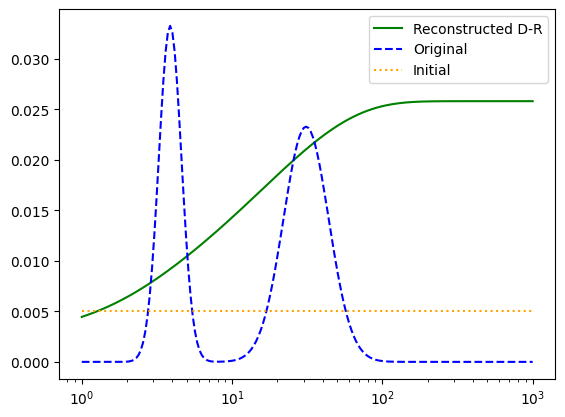

In [47]:
grid_beta = np.logspace(-8,0,100)
NQE_list = [] 

## Naive optimization
for beta in grid_beta:
    res = forward_backward_optimization(beta, K, y, max_iter=1000,x_init=x_init, tol=1e-7)
    NQE = np.sum(((res - x_true.x)**2)/np.sum(x_true.x**2))
    NQE_list.append(NQE)
#gradient inexistant donc refuge dans solution de départ car g2 pas diff partout
best_beta = grid_beta[np.argmin(NQE_list)]
res = forward_backward_optimization(best_beta, K, y, max_iter=1000,x_init=x_init, tol=1e-7)
print("Best beta:", best_beta)
print("Minimum NQE:", np.min(NQE_list))
    
plt.plot(T, res, label='Reconstructed D-R', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.plot(T, x_init, label='Initial', color='orange', linestyle='dotted')
plt.legend()
plt.xscale('log')
plt.show()

On observe que beta a assez peux d'influence ici.

### 4) Douglas Rachford

Converged in 24 iterations.
fin
NQE D-R: 12.460603300388993


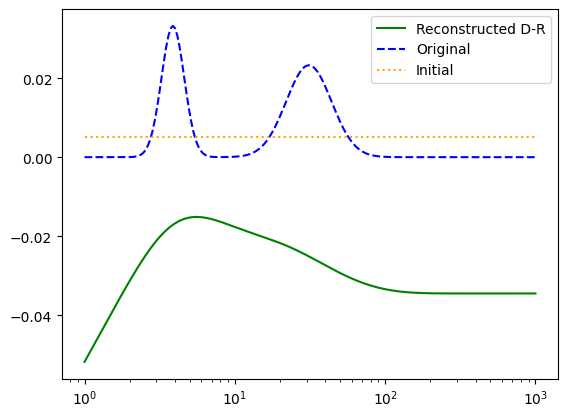

In [48]:
from scipy.special import lambertw

def prox_ent(x, gamma):
    return np.maximum(0,gamma * np.real(lambertw(np.exp((x - gamma) / gamma) / gamma)))


def douglas_rachford(K, y, beta, gamma,x0=x_init, n_iter=200, lamb=1, tol=1e-6):
    xn = x0.copy()
    for n in range(n_iter):      
        tau = gamma * beta
        yn = prox_ent(xn, tau)

        arg = 2.0 * yn - xn
        zn = prox_f(arg, gamma, K, y)

        xn1 = xn + lamb * (zn - yn)

        resid = np.linalg.norm(xn1 - xn)
        if resid < tol:
            xn = xn1
            print(f'Converged in {n} iterations.')
            break

        xn = xn1

    x_est = prox_l1_vec(xn, tau) 
    return x_est

x_sol = douglas_rachford(K, y, beta = 0.01, gamma = 1, n_iter=2000, lamb = 2, tol=1e-6) 
print("fin")
NQE_fb = np.sum(((x_sol - x_true.x)**2)/np.sum((x_true.x**2)))
print("NQE D-R:", NQE_fb)
plt.plot(T, x_sol, label='Reconstructed D-R', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.plot(T, x_init, label='Initial', color='orange', linestyle='dotted')
plt.legend()
plt.xscale('log')
plt.show()


Converged in 387 iterations.
Converged in 128 iterations.
Converged in 44 iterations.
Converged in 25 iterations.
Converged in 23 iterations.
Converged in 35 iterations.
Converged in 73 iterations.
Converged in 156 iterations.
Converged in 345 iterations.
Converged in 649 iterations.
Converged in 387 iterations.
Best beta: 0.0001
Minimum NQE: 0.27413507492969735


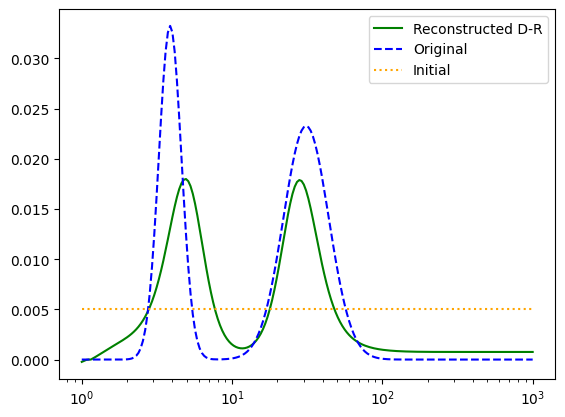

In [49]:
grid_beta = np.logspace(-4,0,10)
NQE_list = [] 

## Naive optimization
for beta in grid_beta:
    res = douglas_rachford(K, y, beta = beta, gamma = 1, n_iter=2000, lamb = 2, tol=1e-6)
    NQE = np.sum(((res - x_true.x)**2)/np.sum(x_true.x**2))
    NQE_list.append(NQE)
#gradient inexistant donc refuge dans solution de départ car g2 pas diff partout
best_beta = grid_beta[np.argmin(NQE_list)]
res = douglas_rachford(K, y, beta = best_beta, gamma = 1, n_iter=2000, lamb = 2, tol=1e-6)
print("Best beta:", best_beta)
print("Minimum NQE:", np.min(NQE_list))
    
plt.plot(T, res, label='Reconstructed D-R', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.plot(T, x_init, label='Initial', color='orange', linestyle='dotted')
plt.legend()
plt.xscale('log')
plt.show()

La NQE est bien meilleure avec $\beta = 0.0001$ (donc avec peu de régularisation) 

### 8)
L'équation : 
$$
\min_{x \in \mathbb{R}^N} \ \mathrm{ent}(x)
\quad \text{subject to} \quad
\|Kx - y\|^2 \le \eta\, M\, \sigma^2 .
$$
est équivalente à :
$$
\min_{x \in \mathbb{R}^N} \ \mathrm{ent}(x) + (\iota_{B(y,\sqrt{\eta\, M\, \sigma^2})} \circ K )(x)
$$

On voit qu'on est dans la situation parfaite pour un ADMM. 

En effet,  $ent \in \Gamma_0$, $ \iota_{B(y,\sqrt{\eta\, M\, \sigma^2})} \in \Gamma_0$, Et, comme $K$ est de rang plein, $K^*K$ est un isomorphisme. On supose $\eta$ suffisament grand pour que les hypothèses d'exsistence et de domaines nécéssaires soient vérifiées. (Comme dans notre cas, y est à composantes positives, pas de problème)

fin
NQE ADMM: 0.30428157192570376


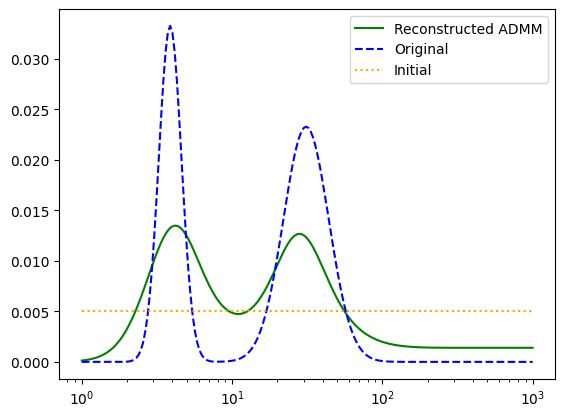

In [ ]:
def prox_iota(x,c,r): 
    # Projection on the closed ball of center c and radius r
    norm = np.linalg.norm(x - c)
    if norm > r:
        x = c + r * (x - c) / norm
    return x

def ADMM(K, y, r, rho, tau, x0, n_iter=200, tol=1e-6):

    x = x0.copy()
    z = K @ x0
    u = np.zeros_like(z)

    for k in range(n_iter):

        # ---- x-update (linearized ADMM) ----
        grad = K.T @ (K @ x - z + u)
        x_new = prox_ent(x - tau * rho * grad, tau)

        # ---- z-update (projection) ----
        z_new = prox_iota(K @ x_new + u, y, r)

        # ---- dual update ----
        u_new = u + K @ x_new - z_new

        # ---- convergence ----
        if np.linalg.norm(x_new - x) < tol:
            print(f"Converged in {k} iterations.")
            break

        x, z, u = x_new, z_new, u_new

    return x
x_sol = ADMM(K, y, r=sigma * np.sqrt(0.001*M), rho=1.0, tau= 0.99/(np.linalg.norm(K, 2)**2), x0=x_init, n_iter=2000, tol=1e-6)
print("fin")
NQE_fb = np.sum(((x_sol - x_true.x)**2)/np.sum((x_true.x**2)))
print("NQE ADMM:", NQE_fb)
plt.plot(T, x_sol, label='Reconstructed ADMM', color='green')
plt.plot(T, x_true.x, label='Original', color='blue', linestyle='dashed')
plt.plot(T, x_init, label='Initial', color='orange', linestyle='dotted')
plt.legend()
plt.xscale('log')
plt.show()
